## Ridge Regression (Model)

In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [17]:
hit = pd.read_csv("hitters.csv")
df = hit.copy()
df = df.dropna()
dms = pd.get_dummies(df[["League", "Division", "NewLeague"]])
dms = dms.astype(int)
y = df["Salary"]
X_ = df.drop(["Salary", "League", "Division", "NewLeague"], axis = 1).astype("float64")
X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [18]:
ridge_model = Ridge(alpha = 0.1).fit(X_train, y_train)

In [19]:
ridge_model

Ridge(alpha=0.1)

In [20]:
ridge_model.coef_

array([ -1.77435737,   8.80240528,   7.29595605,  -3.33257639,
        -2.08316481,   5.42531283,   7.58514945,  -0.13752764,
        -0.20779701,  -0.60361067,   1.7927957 ,   0.72866408,
        -0.68710375,   0.26153564,   0.26888652,  -0.52674278,
       112.14640272, -99.80997876, -48.07152768])

*Farklı lambda değerleri için modelin katsayıları nasıl değişiyor ona bakalım.*

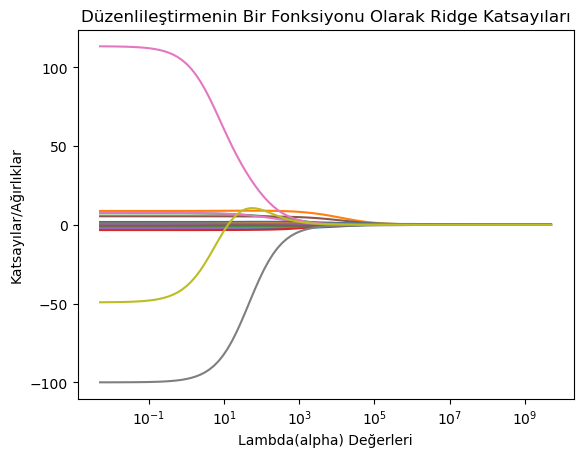

In [22]:
lambdalar = 10**np.linspace(10, -2, 100)*0.5

ridge_model = Ridge()
katsayilar = []

for i in lambdalar:
    #duzenlilestirme
    ridge_model.set_params(alpha = i)
    ridge_model.fit(X_train, y_train)
    katsayilar.append(ridge_model.coef_)

ax = plt.gca()
ax.plot(lambdalar, katsayilar)
ax.set_xscale('log')

plt.xlabel('Lambda(alpha) Değerleri')
plt.ylabel('Katsayılar/Ağırlıklar')
plt.title('Düzenlileştirmenin Bir Fonksiyonu Olarak Ridge Katsayıları');

## Tahmin

In [23]:
y_pred = ridge_model.predict(X_test)

In [25]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(357.0517922282827)

## Model Tuning

*Optimum lambda değerini bulmaya çalışacağız. Burada diğer modellerde olduğu gibi Brute Force ile değil de haızr paketler yardımıyla bu işlemi gerçekleştireceğiz.*

In [37]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline 

In [30]:
lambdalar = 10**np.linspace(10, -2, 100)*0.5

In [48]:
ridge_cv = make_pipeline(StandardScaler(),
                         RidgeCV(alphas = lambdalar,
                                 scoring = "neg_mean_squared_error",
                                )
                        )


In [49]:
ridge_cv.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('ridgecv',
                 RidgeCV(alphas=array([5.00000000e+09, 3.78231664e+09, 2.86118383e+09, 2.16438064e+09,
       1.63727458e+09, 1.23853818e+09, 9.36908711e+08, 7.08737081e+08,
       5.36133611e+08, 4.05565415e+08, 3.06795364e+08, 2.32079442e+08,
       1.75559587e+08, 1.32804389e+08, 1.00461650e+08, 7.59955541e+07,
       5.74878498e+07, 4.34874501...
       3.06795364e+00, 2.32079442e+00, 1.75559587e+00, 1.32804389e+00,
       1.00461650e+00, 7.59955541e-01, 5.74878498e-01, 4.34874501e-01,
       3.28966612e-01, 2.48851178e-01, 1.88246790e-01, 1.42401793e-01,
       1.07721735e-01, 8.14875417e-02, 6.16423370e-02, 4.66301673e-02,
       3.52740116e-02, 2.66834962e-02, 2.01850863e-02, 1.52692775e-02,
       1.15506485e-02, 8.73764200e-03, 6.60970574e-03, 5.00000000e-03]),
                         scoring='neg_mean_squared_error'))])

In [51]:
optimum_lambda = ridge_cv.named_steps["ridgecv"].alpha_
print("Optimum Lambda Değeri:", optimum_lambda)

Optimum Lambda Değeri: 152.69277544167062


*Şimdi optimum değer ile modelimizi yeniden oluşturalım:*

In [53]:
#Artık RidgeCV (deney-yanılma) değil, cevabı bildiğimiz için düz "Ridge" kullanıyoruz.
ridge_tuned = make_pipeline(StandardScaler(),
                            Ridge(alpha=optimum_lambda))

In [54]:
ridge_tuned.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('ridge', Ridge(alpha=np.float64(152.69277544167062)))])

In [55]:
#nihai test hatası

In [56]:
np.sqrt(mean_squared_error(y_test, ridge_tuned.predict(X_test)))

np.float64(386.7249674627307)

*Burada yine bahsetmem gereken bir detay var. Model Tuning işleminden önce rmse değerimiz 357 iken Tuning sonucu kurduğumuz modelin rmse değeri 386. Peki neden arttı? Zaten bu hata değerini azaltmak için Tuning yapmıyor muyduk?*

*Sebep Şu: En başta ayırdığımız X_test verisi, yüzlerce rastgele karıştırma ihtimalinden sadece birisidir. İlk kurduğumuz ayarsız (default lambda=1.0 olan) model, belki de tesadüfi olarak sadece elimizdeki o test setindeki verilere "şans eseri" çok iyi oturan katsayılar üretti.*

*Biz tuning yaparken modeli sadece 1 tane test setine hoş görünmesi için değil; Gelecekte daha önce hiç görmediği yepyeni veriler geldiğinde çökmesin, genellenebilir (robust) olsun diye ayarlarız. Cross-validation, modeli ezberlemekten (Overfitting) koruyan o 152 ceza puanını bu yüzden seçti. Belki elimizdeki spesifik test setinde ufak bir performans kaybı yaşamış olabiliriz, ama modelimiz şu an çok daha istikrarlı ve kararlı hale geldi.*